*Kjersti Stangeland, September 2026*

In [32]:
from glob import glob
import cmocean.cm as cmo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

## Aim of notebook
* Look through the results Maxime got from the lab in the spring semester 2025.
* Get familiar with the data processing methods he did
* Check if his results are correct, are the wave parameters scaled correctly?
* Find out what would be interesting for me to look at further.

__Plan:__

* Make a program such that you can choose a water height, position of probes and a frequency and it will give you the results for all runs.

__Find out__:
- Which equation was used to figure out frequencies and amplitudes?
- What is the modified files?

In [2]:
water_height_folders = ['20 cm', '20 cm no plates', '30 cm', '30 cm no plates', '40 cm', '40 cm no plates']

# Choose a water height to work with
water_height = water_height_folders[0]

In [3]:
# Path to files
basepath = glob('/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs')[0]
positions = ['P0', 'P1', 'P2', 'P3', 'P4']
runs = ['run1', 'run2', 'run3']

if water_height == water_height_folders[0] or water_height == water_height_folders[1]:
    # Frequencies for the given depth
    frequencies = ['f076', 'f092', 'f107', 'f122', 'f137', 'f153']
    amplitude = 'A015'

if water_height == water_height_folders[2] or water_height == water_height_folders[3]:
    # Frequencies for the given depth
    frequencies = ['f059', 'f071', 'f083', 'f095', 'f106', 'f118']
    amplitude = 'A030' 

if water_height == water_height_folders[4]:
    # Frequencies for the given depth
    frequencies = ['f050', 'f060', 'f070', 'f080', 'f090', 'f100']
    amplitude = 'A03'

if water_height == water_height_folders[5]:
    # Frequencies for the given depth
    frequencies = ['f1', 'f05', 'f06', 'f07', 'f08', 'f09']
    amplitude = 'A030'

In [4]:
# /Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P0/f076/f076_A015_P0_run1.csv

In [5]:
# Choose a frequency to work with:
freq = frequencies[0]

# Choose a position to work with:
pos = positions[0]

In [6]:
filepaths = []
for run in runs:
    filepath = f'{basepath}/{water_height}/' + pos + f'/{freq}/{freq}_{amplitude}_{pos}_{run}.csv'
    filepaths.append(filepath)

In [7]:
filepaths

['/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P0/f076/f076_A015_P0_run1.csv',
 '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P0/f076/f076_A015_P0_run2.csv',
 '/Users/kjesta/Desktop/Master prosjekt/Maxime_sine_greier/Maxime-s-Programs/20 cm/P0/f076/f076_A015_P0_run3.csv']

In [8]:
headers = ['time', 'p2', 'p1', 'p4', 'p3', 'speed of sound']

df_run1 = pd.read_csv(filepaths[0], header=None)
df_run2 = pd.read_csv(filepaths[1], header=None)
df_run3 = pd.read_csv(filepaths[2], header=None)

df_run1.columns = headers
df_run2.columns = headers
df_run3.columns = headers

The probes measure water level every 4th millisecond. Acquisition time is 30 seconds.

In [9]:
pd.to_datetime(df_run1.iloc[-1, 0]) - pd.to_datetime(df_run1.iloc[0, 0])

Timedelta('0 days 00:00:30')

As we see, it takes some time for the waves to start. The first 1000-1500 data points are just noise from the probes. Therefore, to clean the data and only evaluate the signal from the passing waves we can subtract the mean of the first 1000 data points.

Text(0.5, 0.93, 'Raw data')

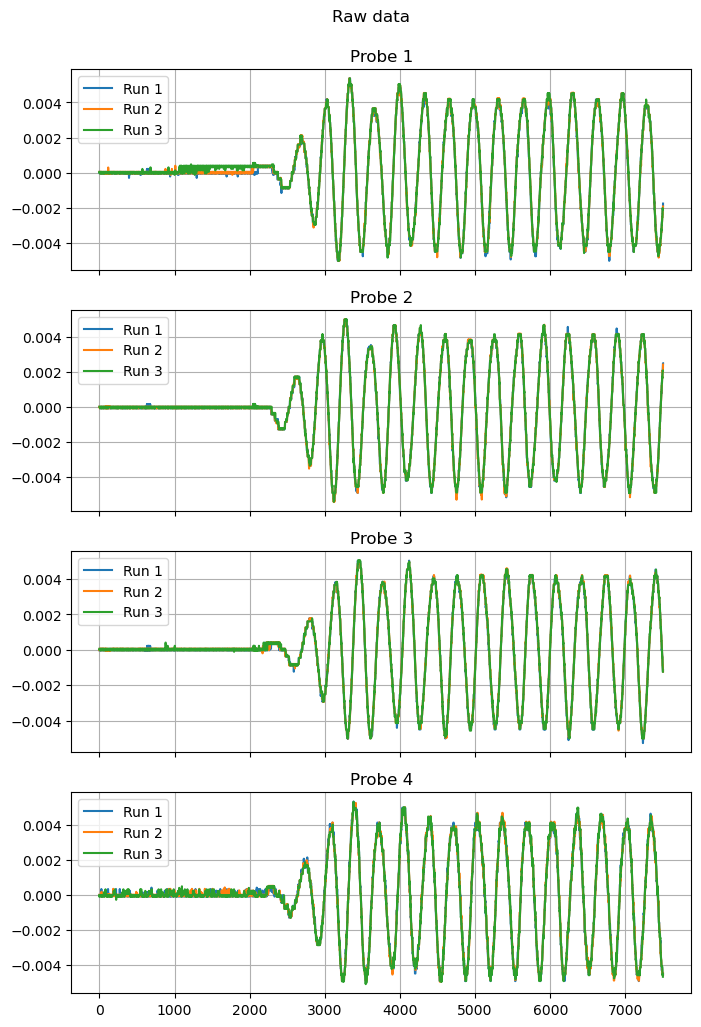

In [30]:
fig, ax = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

ax[0].plot(df_run1['p1'], label='Run 1')
ax[0].plot(df_run2['p1'], label='Run 2')
ax[0].plot(df_run3['p1'], label='Run 3')
ax[0].set_title('Probe 1')

ax[1].plot(df_run1['p2'], label='Run 1')
ax[1].plot(df_run2['p2'], label='Run 2')
ax[1].plot(df_run3['p2'], label='Run 3')
ax[1].set_title('Probe 2')

ax[2].plot(df_run1['p3'], label='Run 1')
ax[2].plot(df_run2['p3'], label='Run 2')
ax[2].plot(df_run3['p3'], label='Run 3')
ax[2].set_title('Probe 3')

ax[3].plot(df_run1['p4'], label='Run 1')
ax[3].plot(df_run2['p4'], label='Run 2')
ax[3].plot(df_run3['p4'], label='Run 3')
ax[3].set_title('Probe 4')

for axs in ax:
    axs.legend(loc='upper left')
    axs.grid()

fig.suptitle('Raw data', y=0.93)

In [12]:
def modify(df):
    '''
    Removes noise from data by subtracting the mean of the first 1000 rows,
    and converts timestamps to datetime values.
    '''
    # Removing noise
    for col in range(1, 5):
        noise = df.iloc[:1000, col].mean()
        df.iloc[:, col] = df.iloc[:, col] - noise

    # Fixing the timestamps
    df['time'] = pd.to_datetime(df['time'])

    return df

In [14]:
run1 = modify(df_run1)
run2 = modify(df_run2)
run3 = modify(df_run3)

Text(0.5, 0.93, 'Raw data')

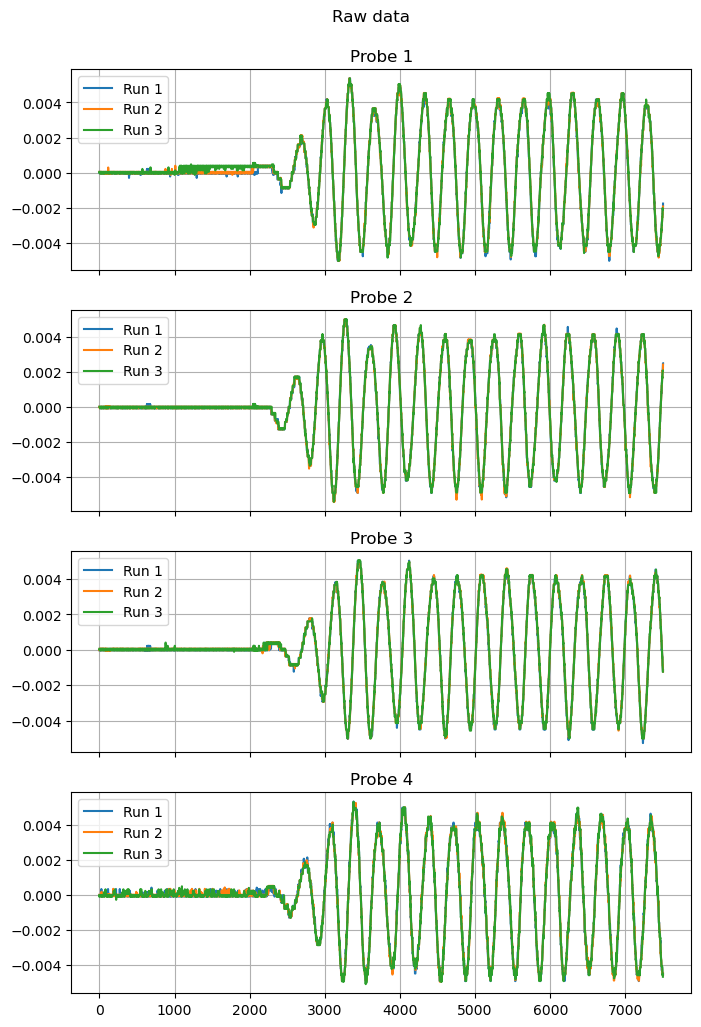

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

ax[0].plot(run1['p1'], label='Run 1')
ax[0].plot(run2['p1'], label='Run 2')
ax[0].plot(run3['p1'], label='Run 3')
ax[0].set_title('Probe 1')

ax[1].plot(run1['p2'], label='Run 1')
ax[1].plot(run2['p2'], label='Run 2')
ax[1].plot(run3['p2'], label='Run 3')
ax[1].set_title('Probe 2')

ax[2].plot(run1['p3'], label='Run 1')
ax[2].plot(run2['p3'], label='Run 2')
ax[2].plot(run3['p3'], label='Run 3')
ax[2].set_title('Probe 3')

ax[3].plot(run1['p4'], label='Run 1')
ax[3].plot(run2['p4'], label='Run 2')
ax[3].plot(run3['p4'], label='Run 3')
ax[3].set_title('Probe 4')

for axs in ax:
    axs.legend(loc='upper left')
    axs.grid()

fig.suptitle('Cleaned data', y=0.93)

When the wave maker starts generating waves, it takes some time for the movement to become linear. As a first guess, I will focus on looking at the 10th wave, and hoping this is when the waves have "settled in". 

To do so, we need to find the row in the dataset where the 10th wave begins. That is, which row is where the 10th wave enters probe 1 at the given position. The time it takes for a given wave crest with a given speed to reach a given position.

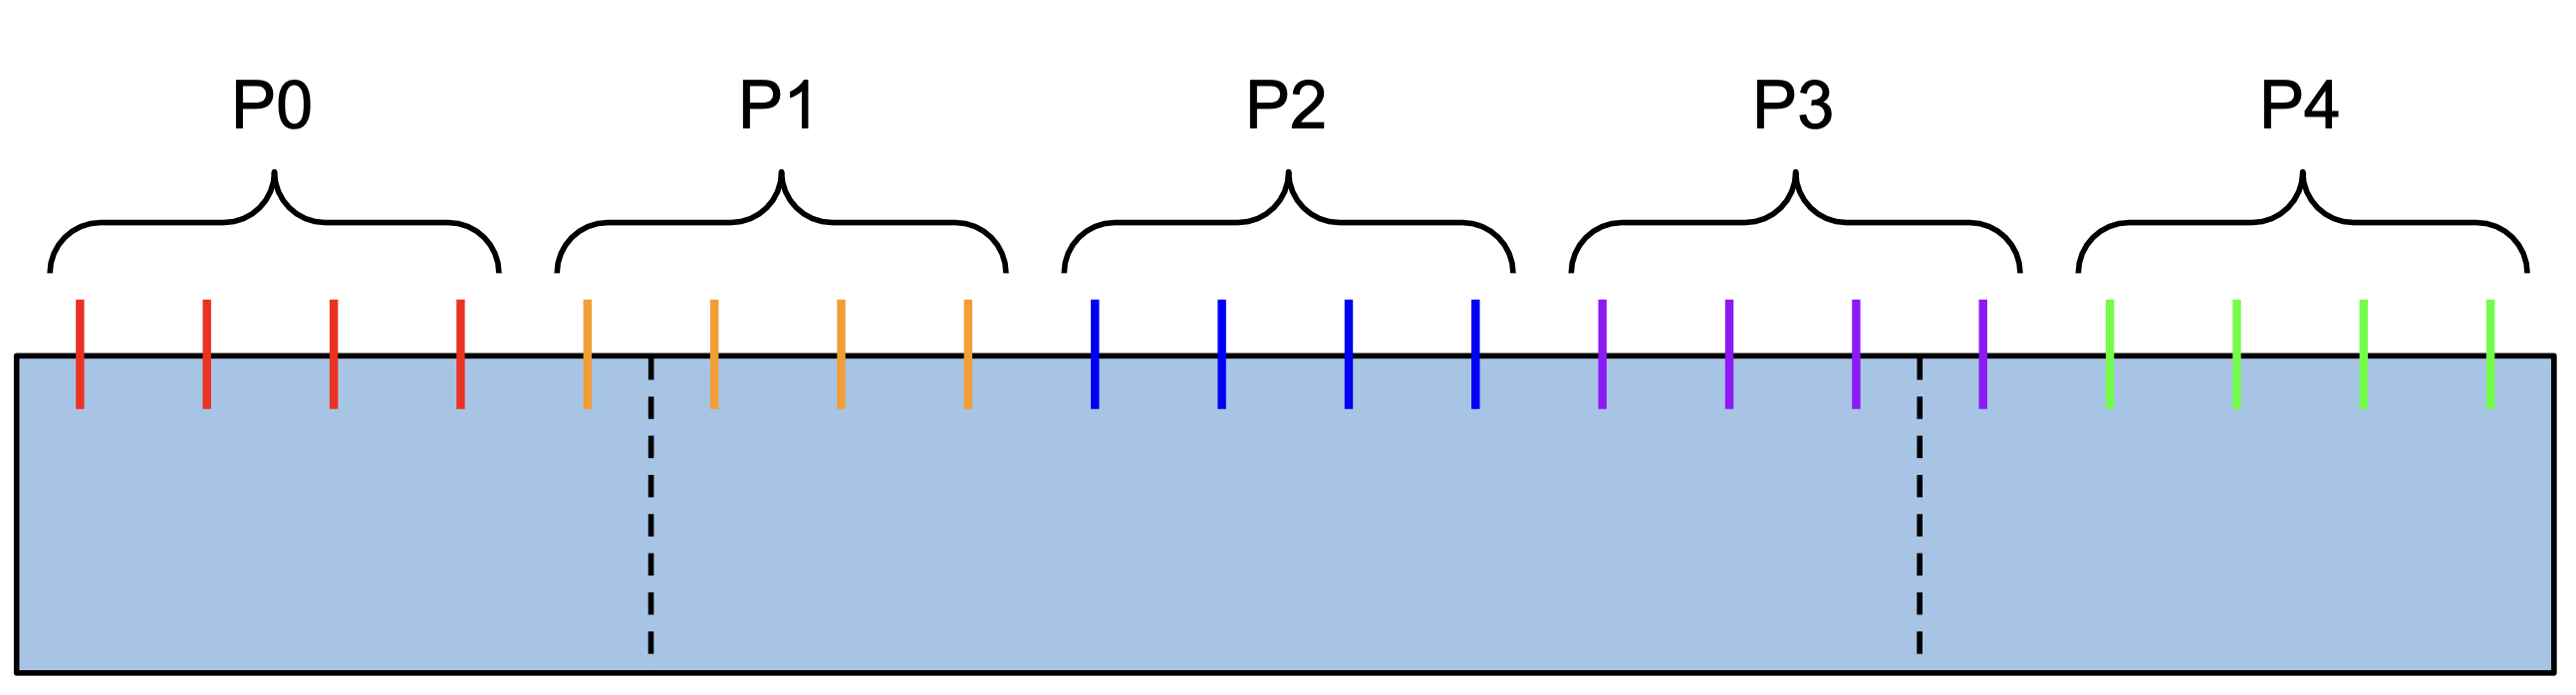

In [33]:
image_path = '/Users/kjesta/Desktop/Master prosjekt/Figurer/probe_positions.png'
display(Image(filename=image_path))

In [34]:
'''
Copied from Maxime, positions of probes at the four rack positions
XA_B, where A: probe number, B: position number
Position is in meters from wave maker
'''
X1_0 = 11.075
X2_0 = 11.38
X3_0 = 11.685
X4_0 = 11.99

X1_1 = 12.247
X2_1 = 12.545
X3_1 = 12.85
X4_1 = 13.155

X1_2 = X1_1 + 1.215
X2_2 = X2_1 + 1.215
X3_2 = X3_1 + 1.215
X4_2 = X4_1 + 1.215

X1_3 = X1_2 + 1.215
X2_3 = X2_2 + 1.215
X3_3 = X3_2 + 1.215
X4_3 = X4_2 + 1.215

X1_4 = X1_3 + 1.215
X2_4 = X2_3 + 1.215
X3_4 = X3_3 + 1.215
X4_4 = X4_3 + 1.215

Viscous boundary layer height for oscillatory flow:

$$\delta= \sqrt{\frac{2 \nu}{2 \pi f}}$$

There will be a boundary layer on the sides of the plates, which is the reason for damping of the waves. The waves push water into the Hele-Shaw cells due to pressure, and inside the walls viscous forces will dampen it out. The larger the viscous boundary layer height, the more damping.

In [ ]:
nu = 10e-6
f = 0.76

delta = np.sqrt((2*nu)/(2*np.pi*f))
print(f'{delta:.6f}')